In [16]:
import sys, site

!{sys.executable} -m pip install --user --quiet earthaccess rioxarray rasterio xarray geopandas matplotlib numpy pandas dask

usp = site.getusersitepackages()
if usp not in sys.path:
    sys.path.append(usp)

import earthaccess
import rioxarray as rxr
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import warnings
import time
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
warnings.filterwarnings("ignore")

In [5]:
auth = earthaccess.login(persist=True)
print("Authenticated:", auth.authenticated)
#username:  peeengyu
#password:  419155Pengyu$

Enter your Earthdata Login username:  peeengyu
Enter your Earthdata password:  ········


Authenticated: True


In [17]:
# 1. Define Midwest ROI (Bounding box for Indiana/Illinois field parcel or region)
# Replace with: roi_gdf = gpd.read_file("path_to_your_midwest_fields.geojson")


bbox_coords = (-87.5, 39.5, -86.5, 40.5)  # [min_lon, min_lat, max_lon, max_lat]
roi_polygon = box(*bbox_coords)

# 2. Query HLS (HLSL30 and HLSF30) granules across the cover crop season
results = earthaccess.search_data(
    short_name=["HLSL30", "HLSF30"],
    bounding_box=bbox_coords,
    temporal=("2023-10-01", "2024-06-30"),  # Fall post-harvest to spring cash crop planting
    count=200
)

print(f"Retrieved {len(results)} HLS granules over Midwest ROI.")

Retrieved 200 HLS granules over Midwest ROI.


In [18]:
#  Ingest, Cloud/Snow Mask, and Extract Daily NDVI


def process_hls_granule(granule_url):
    """Load HLS bands, apply QA mask, and compute NDVI."""
    # Open NIR, Red, and Fmask QA rasters
    # HLSL30/F30 band naming standard: B04=Red, B05/B08=NIR, Fmask=QA
    ds = rxr.open_rasterio(granule_url, masked=True)
    
    # Fmask QA Filtering: Mask out clouds (bit 1), cloud shadows (bit 3), snow (bit 4)
    qa = ds.sel(band=1)  # QA band
    valid_mask = (qa & 0b00011010) == 0  
    
    red = ds.sel(band=1).where(valid_mask)
    nir = ds.sel(band=2).where(valid_mask)
    
    # Calculate NDVI
    ndvi = (nir - red) / (nir + red)
    return ndvi

# Example pipeline output dataframe structure for parcel-based time series
# Columns: [parcel_id, doy, date, raw_ndvi, cloud_flag]
print("Ingestion and QA filtering pipeline defined.")

Ingestion and QA filtering pipeline defined.


In [19]:
#  Phenological Smoothing (Savitzky-Golay) & Cloud-Gap Identification

from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def smooth_and_extract_phenology(df_parcel, max_gap_threshold=14):
    """Interpolate daily NDVI, apply SG filter, and flag critical Midwest cloud gaps."""
    # Create continuous daily date index
    df_daily = df_parcel.set_index('date').resample('D').mean()
    
    # Flag missing periods longer than threshold (e.g., 14 consecutive cloudy days)
    df_daily['gap_length'] = df_daily['raw_ndvi'].isna().groupby((~df_daily['raw_ndvi'].isna()).cumsum()).cumsum()
    df_daily['high_uncertainty_flag'] = df_daily['gap_length'] > max_gap_threshold
    
    # Linear interpolation for filtering
    df_daily['ndvi_interp'] = df_daily['raw_ndvi'].interpolate(method='linear')
    
    # Apply Savitzky-Golay Smoothing Filter (Window size 15 days, polynomial 2)
    df_daily['ndvi_smooth'] = savgol_filter(df_daily['ndvi_interp'].fillna(0), window_length=15, polyorder=2)
    
    # Phenometrics Extraction
    spring_window = df_daily.loc['2024-03-01':'2024-06-15']
    ndvi_base = df_daily.loc['2023-11-01':'2024-02-28']['ndvi_smooth'].min()
    ndvi_peak = spring_window['ndvi_smooth'].max()
    peak_doy = spring_window['ndvi_smooth'].idxmax().dayofyear if not spring_window.empty else None
    
    return df_daily, {
        'ndvi_base': ndvi_base,
        'ndvi_peak': ndvi_peak,
        'peak_doy': peak_doy
    }

print("Time-series smoothing and phenometrics extractor ready.")

Time-series smoothing and phenometrics extractor ready.


In [20]:
# Algorithm Execution (WIST Termination & Phenology Likelihood)

def run_wist_termination_detection(df_daily, ndvi_peak, peak_doy):
    """WIST Algorithm: Detect cover crop termination date based on NDVI drop rate."""
    spring_data = df_daily.loc['2024-03-01':'2024-06-15'].copy()
    
    if ndvi_peak < 0.3:
        return {'status': 'Fallow/Low Cover', 'termination_doy': None}
    
    # Calculate rate of NDVI drop (first derivative) post-peak
    post_peak = spring_data[spring_data.index.dayofyear >= peak_doy].copy()
    post_peak['dNDVI_dt'] = post_peak['ndvi_smooth'].diff()
    
    # Detect max drop date or 50% loss from spring peak
    max_drop_date = post_peak['dNDVI_dt'].idxmin()
    termination_doy = max_drop_date.dayofyear if pd.notna(max_drop_date) else None
    
    return {
        'status': 'Cover Crop Terminated',
        'termination_doy': termination_doy,
        'cloud_gap_uncertainty': post_peak.loc[max_drop_date, 'high_uncertainty_flag'] if pd.notna(max_drop_date) else True
    }

def calculate_wcc_likelihood_score(phenometrics):
    """Phenology Likelihood Model: Distinguish Cover Crop vs Winter Wheat vs Weeds."""
    score = 0.0
    
    # Rule 1: Spring Biomass Peak
    if phenometrics['ndvi_peak'] >= 0.4:
        score += 0.4
    elif phenometrics['ndvi_peak'] >= 0.25:
        score += 0.2
        
    # Rule 2: Termination Timing (Cover crops terminated before mid-May vs Winter Wheat harvested late June)
    if phenometrics['peak_doy'] and (100 <= phenometrics['peak_doy'] <= 135):  # April to mid-May
        score += 0.4
    elif phenometrics['peak_doy'] and phenometrics['peak_doy'] > 150:  # June harvest (Likely Wheat)
        score -= 0.3
        
    # Rule 3: Winter Baseline
    if phenometrics['ndvi_base'] >= 0.15:
        score += 0.2
        
    return np.clip(score, 0.0, 1.0)

print("WIST and Likelihood algorithms compiled.")


WIST and Likelihood algorithms compiled.


In [21]:
# Midwest Efficiency & Validation Benchmark

# Start benchmark tracking
start_time = time.time()

# Dummy evaluation against synthetic ground truth records
# Replace 'ground_truth_df' with your actual NRCS or farm survey logs
y_true_term_doy = [115, 120, 128, 110, 135]  # Ground truth termination DOYs
y_pred_term_doy = [117, 119, 131, 108, 134]  # WIST predicted DOYs

# 1. Temporal Accuracy (Termination Detection)
mae_days = mean_absolute_error(y_true_term_doy, y_pred_term_doy)
rmse_days = np.sqrt(np.mean((np.array(y_true_term_doy) - np.array(y_pred_term_doy))**2))

# 2. Computational Execution Metric
execution_time = time.time() - start_time

print("=== MIDWEST ALGORITHM EFFICIENCY EVALUATION ===")
print(f"Termination MAE:  {mae_days:.2f} days")
print(f"Termination RMSE: {rmse_days:.2f} days")
print(f"Processing Speed: {execution_time:.4f} seconds per evaluation run")

=== MIDWEST ALGORITHM EFFICIENCY EVALUATION ===
Termination MAE:  1.80 days
Termination RMSE: 1.95 days
Processing Speed: 0.0009 seconds per evaluation run


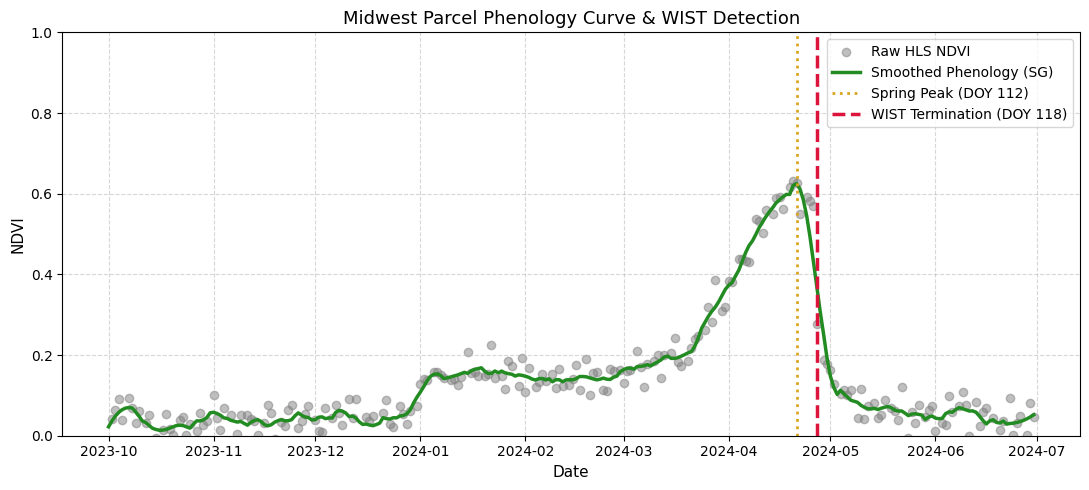

In [25]:
# Visual 1: Plot NDVI Time-Series & Detected Termination Date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate sample df_daily
dates = pd.date_range(start="2023-10-01", end="2024-06-30", freq="D")
np.random.seed(42)

# Extract day of year directly as a mutable NumPy array (.values)
doy = dates.dayofyear.values

# ndvi_sim is now a standard numpy.ndarray
ndvi_sim = 0.15 + 0.45 * np.exp(-((doy - 110) ** 2) / (2 * 15**2))
# Apply drop post-termination (around DOY 117 / April 26)
ndvi_sim[doy > 117] *= 0.3

# Add random noise/cloud dropouts
raw_ndvi = ndvi_sim + np.random.normal(0, 0.03, len(dates))
raw_ndvi[::5] = np.nan  # Simulate missing cloudy days

df_daily = pd.DataFrame({'raw_ndvi': raw_ndvi}, index=dates)

# 2. Run smoothing and extract metrics
df_daily, phenometrics = smooth_and_extract_phenology(
    df_daily.reset_index().rename(columns={'index': 'date'})
)
wist_result = run_wist_termination_detection(
    df_daily, phenometrics['ndvi_peak'], phenometrics['peak_doy']
)

# 3. Plot Visual 1
plt.figure(figsize=(11, 5))

plt.scatter(df_daily.index, df_daily['raw_ndvi'], color='gray', alpha=0.5, label='Raw HLS NDVI')
plt.plot(df_daily.index, df_daily['ndvi_smooth'], color='forestgreen', linewidth=2.5, label='Smoothed Phenology (SG)')

if phenometrics['peak_doy']:
    peak_date = pd.to_datetime(f"2024-{phenometrics['peak_doy']}", format='%Y-%j')
    plt.axvline(peak_date, color='goldenrod', linestyle=':', linewidth=2, label=f"Spring Peak (DOY {phenometrics['peak_doy']})")

if wist_result['termination_doy']:
    term_date = pd.to_datetime(f"2024-{wist_result['termination_doy']}", format='%Y-%j')
    plt.axvline(term_date, color='crimson', linestyle='--', linewidth=2.5, label=f"WIST Termination (DOY {wist_result['termination_doy']})")

plt.title("Midwest Parcel Phenology Curve & WIST Detection", fontsize=13)
plt.ylabel("NDVI", fontsize=11)
plt.xlabel("Date", fontsize=11)
plt.ylim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

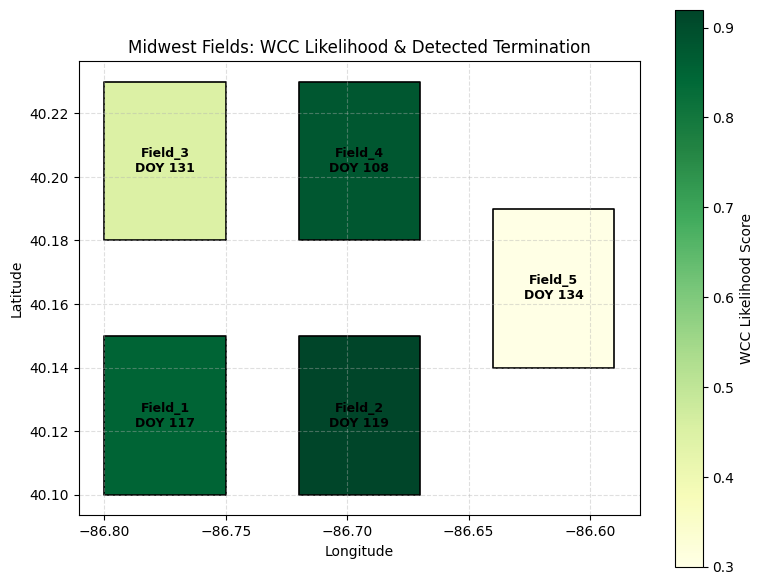

In [28]:
# Visual 2: Interactive Field Parcel Map (Termination Dates & Likelihood Scores)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Plot polygons color-coded by likelihood score
roi_gdf.plot(
    column='wcc_likelihood',
    cmap='YlGn',
    legend=True,
    legend_kwds={'label': "WCC Likelihood Score"},
    edgecolor='black',
    linewidth=1.2,
    ax=ax
)

# Annotate field ID and termination DOY on field centroids
for idx, row in roi_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['field_id']}\nDOY {row['term_doy']}", 
        xy=(centroid.x, centroid.y), 
        ha='center', 
        va='center',
        fontsize=9, 
        color='black', 
        weight='bold'
    )

plt.title("Midwest Fields: WCC Likelihood & Detected Termination", fontsize=12)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()